In [ ]:
#Import necessay libraries
import numpy as np
import pandas as pd
import re

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
#Read the data
file_path = '/content/fomc_corpus.csv'
df = pd.read_csv(file_path, encoding="utf-8-sig")
df.head(3)

,url,doc_type,date,text,year,meeting
0,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-03-29,TRANSCRIPT FEDERAL OPEN MARKET COMMITTEE MEETI...,1976,FOMC19760329meeting.pdf
1,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-04-20,TRANSCRIPT FEDERAL OPEN MARKET COMMITTEE MEETI...,1976,FOMC19760420meeting.pdf
2,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-05-18,TRANSCRIPT FEDERAL OPEN MARKET COMMITTEE MEETI...,1976,FOMC19760518meeting.pdf


In [ ]:
#Check for duplicates
print("No of duplicate records in the dataset:", df.duplicated().sum())
print("No of duplicate dates in the dataset:",df['date'].duplicated().sum())

No of duplicate records in the dataset: 0
No of duplicate dates in the dataset: 238


In [ ]:
#Keep only unique dates
df.drop_duplicates(subset=['date'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 535 entries, 0 to 771
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   url       535 non-null    object
 1   doc_type  535 non-null    object
 2   date      535 non-null    object
 3   text      535 non-null    object
 4   year      535 non-null    int64 
 5   meeting   495 non-null    object
dtypes: int64(1), object(5)
memory usage: 29.3+ KB


In [ ]:
#Check for the type of documents
df['doc_type'].value_counts()

,count
doc_type,
transcript,293
statement,242


In [ ]:
#Convert date column to datetime datatype
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 535 entries, 0 to 771
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   url       535 non-null    object        
 1   doc_type  535 non-null    object        
 2   date      535 non-null    datetime64[ns]
 3   text      535 non-null    object        
 4   year      535 non-null    int64         
 5   meeting   495 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 29.3+ KB


In [ ]:
#Define regular sentence patterns to remove
import html, unicodedata
PATTERNS = [
    r"TRANSCRIPT\s+FEDERAL OPEN MARKET COMMITTEE MEETING[\s\S]*?All information deleted in this manner is exempt from disclosure under applicable provisions of the Freedom of Information Act\.\s*",
    r"Staff Statements Appended to the Transcript\s*",
    r"Content\s+last\s+modified\s+\d{2}/\d{2}/\d{2}(?:\d{2})?\.*\s*",
    r"\d{1,2}/\d{1,2}/\d{2}\s+Meeting of (?:the\s+)?Federal Open Market Committee\s+[A-Za-z]+\s+\d{1,2}(?:[-–]\d{1,2})?,\s+\d{4}\s*",
    r"Meeting of (?:the\s+)?Federal Open Market Committee\s+[A-Za-z]+\s+\d{1,2}(?:[-–]\d{1,2})?,\s+\d{4}\s*",
    r"Federal\s+Reserve\s+Board\s*[-–]\s*Federal\s+Reserve\s+issues\s+FOMC\s+statement.*?For\s+release\s+at\s+\d{1,2}:\d{2}\s+p\.m\.\s+EDT\s+Share\s*",
    r"Federal\s+Reserve\s+Board\s*[-–]\s*Implementation\s+Note\s+issued.*?Federal\s+Open\s+Market\s+Committee.*?in\s+its\s+statement\s+on\s+[A-Za-z]+\s+\d{1,2},\s+\d{4}:\s*",
    r"Federal\s+Reserve\s+Board\s*[-–]\s*Federal\s+Open\s+Market\s+Committee\s+announces.*?Press\s+Releases.*?Press\s+Release\s+[A-Za-z]+\s+\d{1,2},\s+\d{4}\s*",
    r"FRB:\s*Press Release\s*--\s*FOMC statement\s*--[\s\S]*?Release Date:\s*[A-Za-z]+\s+\d{1,2},\s*\d{4}\s*",
    r"Conference Call.*?on\s+[A-Za-z]+\s+\d{1,2},\s+\d{4}(?:,?\s+at\s+\d{1,2}:\d{2}\s*(?:a\.m\.|p\.m\.)?)?\s*"
]

FLAGS = re.IGNORECASE | re.DOTALL | re.MULTILINE

CONTROL_CHARS = re.compile(r"[\u0000-\u0008\u000B\u000C\u000E-\u001F\u007F]")

In [ ]:
#Clean the text
def clean_text(text: str) -> str:
    s = text or ""
    # Optional but safe:
    s = html.unescape(s)
    s = unicodedata.normalize("NFKC", s)

    for pat in PATTERNS:
        s = re.sub(pat, "", s, flags=FLAGS)

   # Remove BOMs
    s = s.replace("\ufeff", "").replace("\u00ef\u00bb\u00bf", "")

    # De-hyphenate line-wrapped words
    s = re.sub(r"(\w)-\s*\n\s*(\w)", r"\1\2", s)

    # Whitespace hygiene (don’t kill punctuation; VADER likes it)
    s = re.sub(r"[ \t]+\n", "\n", s)   # trim spaces before newline
    s = re.sub(r"\n{3,}", "\n\n", s)   # collapse 3+ newlines to 2
    s = CONTROL_CHARS.sub("", s)
    s = re.sub(r"[ \t]{2,}", " ", s)

    return s.strip()

In [ ]:
#Apply text cleaning
df['text'] = df['text'].apply(clean_text)
df.head(2)

,url,doc_type,date,text,year,meeting
0,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-03-29,"Mr. Kalchbrenner, Adviser FEDERAL OPEN MARKET ...",1976,FOMC19760329meeting.pdf
1,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-04-20,A meeting of the Federal Open Market Committee...,1976,FOMC19760420meeting.pdf


In [ ]:
df.tail(2)

,url,doc_type,date,text,year,meeting
770,https://www.federalreserve.gov/newsevents/pres...,statement,2025-08-22,Federal Open Market Committee announces approv...,2025,monetary20250822a.htm
771,https://www.federalreserve.gov/newsevents/pres...,statement,2025-09-17,Recent indicators suggest that growth of econo...,2025,monetary20250917a.htm


In [ ]:
#Compute the text length
df['text_len'] = df['text'].apply(len)
df.head(2)

,url,doc_type,date,text,year,meeting,text_len
0,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-03-29,"Mr. Kalchbrenner, Adviser FEDERAL OPEN MARKET ...",1976,FOMC19760329meeting.pdf,114446
1,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-04-20,A meeting of the Federal Open Market Committee...,1976,FOMC19760420meeting.pdf,215941


#Sentiment analysis and Label assignment

In [ ]:
import math, torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
# ---- Config ----
MODEL  = "ProsusAI/finbert"   # finance sentiment: negative / neutral / positive
MAX_LEN = 512                 # Max length of tokens
STRIDE  = 64                  # overlap between chunks
BATCH   = 32                  # chunk-batch size;
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# ---- Load model/tokenizer ----
tok = AutoTokenizer.from_pretrained(MODEL, use_fast=True)
mdl = AutoModelForSequenceClassification.from_pretrained(MODEL).to(DEVICE).eval()
id2label = mdl.config.id2label

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [ ]:
cfg = mdl.config
if isinstance(cfg.id2label, dict):
    id2label = {int(k): str(v).lower() for k, v in cfg.id2label.items()}
else:
    id2label = {i: str(lbl).lower() for i, lbl in enumerate(cfg.id2label)}
if isinstance(cfg.label2id, dict):
    label2id = {str(k).lower(): int(v) for k, v in cfg.label2id.items()}
else:
    label2id = {v: k for k, v in id2label.items()}

pos_idx = label2id.get("positive", None)
neg_idx = label2id.get("negative", None)

In [ ]:
#splits long text into overlapping chunks (windows) that each fit into the model’s max length
def encode_chunks(text: str, max_len=MAX_LEN, stride=STRIDE):

   #Handle empty of invalid inputs
    if not isinstance(text, str) or not text.strip():
        ids = tok.build_inputs_with_special_tokens([])
        pad = max_len - len(ids)
        return [ids + [tok.pad_token_id]*pad], [[1]*len(ids) + [0]*pad]

    #Tokenize the text
    ids = tok.encode(text, add_special_tokens=False)

   #Determine chunk size & step
    inner = max_len - tok.num_special_tokens_to_add(pair=False)
    inner = max(inner, 1)
    step = max(inner - stride, 1)

    chunks_ids, chunks_attn = [], []
    #Create overlapping chunks
    for start in range(0, len(ids), step):
        end = min(start + inner, len(ids))
        core = ids[start:end]
        #Add special tokens + padding
        with_special = tok.build_inputs_with_special_tokens(core)
        attn = [1] * len(with_special)
        pad = max_len - len(with_special)
        if pad > 0:
            with_special = with_special + [tok.pad_token_id] * pad
            attn = attn + [0] * pad

        #Append to outputs
        chunks_ids.append(with_special)
        chunks_attn.append(attn)
        if end == len(ids):
            break
    return chunks_ids, chunks_attn

In [ ]:
@torch.no_grad()
def score_long_text(text: str):
  #Use encode chunks to tokenize into overlapping chunks
    ids_list, attn_list = encode_chunks(text)
    logits_all = []

    #run the model on each chunk
    for i in range(0, len(ids_list), BATCH):
        batch_ids  = torch.tensor(ids_list[i:i+BATCH],  dtype=torch.long, device=DEVICE)
        batch_attn = torch.tensor(attn_list[i:i+BATCH], dtype=torch.long, device=DEVICE)
        with torch.autocast(device_type=DEVICE, enabled=(DEVICE=="cuda")):
            logits = mdl(input_ids=batch_ids, attention_mask=batch_attn).logits
        logits_all.append(logits)

    #Aggregate the results
    agg = torch.cat(logits_all, dim=0).mean(dim=0)
    probs = torch.softmax(agg, dim=-1).cpu().numpy()
    pred = int(np.argmax(probs))

    top_label = id2label[pred]
    confidence = float(probs[pred])

    label_probs = {id2label[i]: float(probs[i]) for i in range(len(probs))}
    p_pos = label_probs.get("positive", 0.0) if pos_idx is None else float(probs[pos_idx])
    p_neg = label_probs.get("negative", 0.0) if neg_idx is None else float(probs[neg_idx])
    score = p_pos - p_neg  # in [-1, 1]

    # return id2label[pred].lower(), float(probs[pred])
    return top_label, confidence, score

In [ ]:
# ---- Ekman emotions model (Joy -> Happiness) ----
EMO_MODEL = "j-hartmann/emotion-english-distilroberta-base"  # 7 labels incl. neutral
emo_tok = AutoTokenizer.from_pretrained(EMO_MODEL, use_fast=True)
emo_mdl = AutoModelForSequenceClassification.from_pretrained(EMO_MODEL).to(DEVICE).eval()

# Build robust id<->label maps (lowercased)
emo_cfg = emo_mdl.config
if isinstance(emo_cfg.id2label, dict):
    emo_id2label = {int(k): str(v).lower() for k, v in emo_cfg.id2label.items()}
else:
    emo_id2label = {i: str(lbl).lower() for i, lbl in enumerate(emo_cfg.id2label)}

# Map model labels -> Ekman
# Model uses: anger, disgust, fear, joy, neutral, sadness, surprise
TO_EKMAN = {
    "anger": "anger",
    "disgust": "disgust",
    "fear": "fear",
    "joy": "happiness",   # map joy -> happiness
    "sadness": "sadness",
    "surprise": "surprise",
    # "neutral" is kept separate (not part of the six)
}
EKMAN_ORDER = ["anger", "disgust", "fear", "happiness", "sadness", "surprise"]


tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

In [ ]:
@torch.no_grad()
def score_long_text_ekman(text: str):
    """
    Returns:
      - ekman_top: top Ekman label among the six (string)
      - ekman_conf: its probability (after re-normalizing across the six)
      - ekman_probs: dict of normalized Ekman probs for the six (sum to 1)
      - neutral_prob: model's raw neutral probability (separate)
    """
    # Tokenize into chunks using the EMO tokenizer (share your same windowing)
    ids_list, attn_list = encode_chunks(text)

    logits_all = []
    for i in range(0, len(ids_list), BATCH):
        batch_ids  = torch.tensor(ids_list[i:i+BATCH],  dtype=torch.long, device=DEVICE)
        batch_attn = torch.tensor(attn_list[i:i+BATCH], dtype=torch.long, device=DEVICE)
        with torch.autocast(device_type=DEVICE, enabled=(DEVICE=="cuda")):
            logits = emo_mdl(input_ids=batch_ids, attention_mask=batch_attn).logits  # [n,7]
        logits_all.append(logits)

    # Average chunk logits, softmax once
    agg = torch.cat(logits_all, dim=0).mean(dim=0)
    probs = torch.softmax(agg, dim=-1).cpu().numpy()

    # Label -> prob (raw, includes neutral)
    raw = {emo_id2label[i]: float(probs[i]) for i in range(len(probs))}
    neutral_prob = raw.get("neutral", 0.0)

    # Collect only Ekman-six, then re-normalize to sum to 1
    six_raw = {}
    for src_label, p in raw.items():
        if src_label in TO_EKMAN:
            six_raw.setdefault(TO_EKMAN[src_label], 0.0)
            six_raw[TO_EKMAN[src_label]] += p

    s = sum(six_raw.values()) or 1.0
    ekman_probs = {k: v / s for k, v in six_raw.items()}

    # Ensure fixed order (and presence) for downstream use
    for k in EKMAN_ORDER:
        ekman_probs.setdefault(k, 0.0)

    ekman_top = max(ekman_probs.items(), key=lambda kv: kv[1])[0]
    ekman_conf = ekman_probs[ekman_top]

    return ekman_top, float(ekman_conf), ekman_probs, float(neutral_prob)


In [ ]:
def label_dataframe_with_bert_and_ekman(df: pd.DataFrame, text_col="text"):
    labels, confs, scores = [], [], []           # from FinBERT
    emo_labels, emo_confs = [], []               # top Ekman label & conf
    emo_neutral = []                              # raw neutral prob (not in six)
    # Per-emotion columns (Ekman-normalized)
    emo_cols = {k: [] for k in EKMAN_ORDER}

    for txt in tqdm(df[text_col].fillna("").astype(str).tolist(), desc="Scoring (FinBERT + Ekman)"):
        # FinBERT
        lab, conf, sc = score_long_text(txt)  # your function updated earlier to also return 'score'
        labels.append(lab); confs.append(conf); scores.append(sc)

        # Ekman
        e_lab, e_conf, e_probs, e_neu = score_long_text_ekman(txt)
        emo_labels.append(e_lab); emo_confs.append(e_conf); emo_neutral.append(e_neu)
        for k in EKMAN_ORDER:
            emo_cols[k].append(e_probs.get(k, 0.0))

    out = df.copy()
    # FinBERT outputs
    out["sentiment"] = labels
    out["conf"]      = confs
    out["score"]     = scores            # in [-1, 1]

    # Ekman outputs
    out["emotion_label"]    = emo_labels        # top of the six
    # out["ekman_conf"]     = emo_confs         # prob among the six
    out["emotion_neutral"]  = emo_neutral       # model's raw neutral prob
    for k in EKMAN_ORDER:
        out[f"emotion_{k}"] = emo_cols[k]       # normalized across six; sums to 1 across these

    return out

# Run:
df = label_dataframe_with_bert_and_ekman(df, text_col="text")
df.head()

Scoring (FinBERT + Ekman):   0%|          | 0/535 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (26270 > 512). Running this sequence through the model will result in indexing errors


model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

,url,doc_type,date,text,year,meeting,text_len,sentiment,conf,score,emotion_label,emotion_neutral,emotion_anger,emotion_disgust,emotion_fear,emotion_happiness,emotion_sadness,emotion_surprise
0,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-03-29,"Mr. Kalchbrenner, Adviser FEDERAL OPEN MARKET ...",1976,FOMC19760329meeting.pdf,114446,neutral,0.857422,-0.041656,happiness,0.131836,0.118514,0.002651,0.314349,0.324190,0.048959,0.191337
1,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-04-20,A meeting of the Federal Open Market Committee...,1976,FOMC19760420meeting.pdf,215941,neutral,0.817871,-0.026917,happiness,0.133057,0.158297,0.002581,0.221813,0.345324,0.041299,0.230685
2,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-05-18,"Mr. Sternlight, Deputy Manager for Domestic Op...",1976,FOMC19760518meeting.pdf,149622,neutral,0.823730,-0.006775,happiness,0.137695,0.122318,0.002380,0.256952,0.332976,0.053054,0.232319
3,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-06-22,A meeting of the Federal Open Market Committee...,1976,FOMC19760622meeting.pdf,120660,neutral,0.762695,-0.050903,happiness,0.124512,0.126373,0.002466,0.295545,0.302794,0.054090,0.218731
4,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-07-20,A meeting of the Federal Open Market Committee...,1976,FOMC19760720meeting.pdf,204244,neutral,0.780762,-0.065552,happiness,0.131958,0.109672,0.002305,0.221593,0.386944,0.057050,0.222437


In [ ]:
print(df["sentiment"].value_counts(), df["conf"].describe())

sentiment
neutral     459
negative     59
positive     17
Name: count, dtype: int64 count    535.000000
mean       0.680171
std        0.134471
min        0.374756
25%        0.572998
50%        0.689941
75%        0.785645
max        0.936523
Name: conf, dtype: float64


In [ ]:
df['emotion_label'].value_counts()

,count
emotion_label,
fear,248
happiness,203
surprise,72
anger,9
sadness,3


### Word Cloud

In [ ]:
text_data = ""

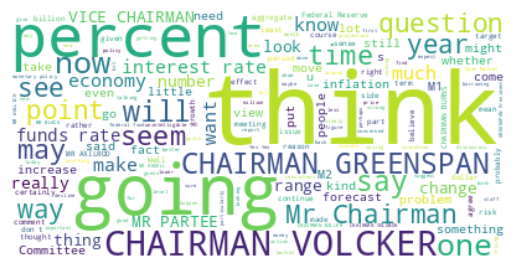

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text_data = " ".join(df["text"])
wordcloud = WordCloud(background_color="white").generate(text_data)

plt.imshow(wordcloud, interpolation="bilinear")
plt.savefig("fullTextWordCloud.png", dpi=300, bbox_inches="tight")
plt.axis("off")
plt.show()

In [ ]:
statement_df = df.loc[df['doc_type'] == 'statement']
statement_df.head(3)

,url,doc_type,date,text,year,meeting,text_len,sentiment,conf,score,emotion_label,emotion_neutral,emotion_anger,emotion_disgust,emotion_fear,emotion_happiness,emotion_sadness,emotion_surprise
231,https://www.federalreserve.gov/fomc/19940204de...,statement,1994-02-04,For immediate release Chairman Alan Greenspan ...,1994,19940204default.htm,735,neutral,0.864258,0.048309,surprise,0.072327,0.026658,0.001022,0.034436,0.063610,0.018073,0.856201
234,https://www.federalreserve.gov/fomc/19940322de...,statement,1994-03-22,For immediate release Chairman Alan Greenspan ...,1994,19940322default.htm,357,neutral,0.870117,0.048035,surprise,0.097717,0.080757,0.001839,0.092863,0.076495,0.304900,0.443146
237,https://www.federalreserve.gov/fomc/19940418de...,statement,1994-04-18,For immediate release Chairman Alan Greenspan ...,1994,19940418default.htm,337,neutral,0.895996,0.020111,sadness,0.091064,0.077296,0.001599,0.106173,0.048285,0.458806,0.307841


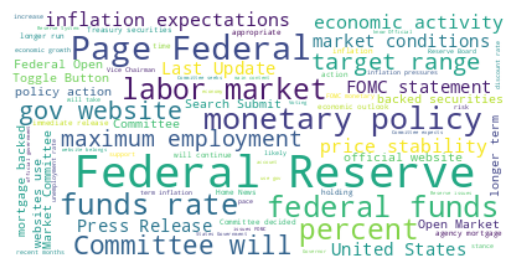

In [ ]:
statement_text = " ".join(statement_df["text"])
wordcloud = WordCloud(background_color="white").generate(statement_text)

plt.imshow(wordcloud, interpolation="bilinear")
plt.savefig("statementWordCloud.png", dpi=300, bbox_inches="tight")
plt.axis("off")
plt.show()

In [ ]:
statement_df.to_csv("fomc_statement.csv", index=False)

In [ ]:
transcript_df = df.loc[df['doc_type'] == 'transcript']
transcript_df.head(3)

,url,doc_type,date,text,year,meeting,text_len,sentiment,conf,score,emotion_label,emotion_neutral,emotion_anger,emotion_disgust,emotion_fear,emotion_happiness,emotion_sadness,emotion_surprise
0,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-03-29,"Mr. Kalchbrenner, Adviser FEDERAL OPEN MARKET ...",1976,FOMC19760329meeting.pdf,114446,neutral,0.857422,-0.041656,happiness,0.131836,0.118514,0.002651,0.314349,0.324190,0.048959,0.191337
1,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-04-20,A meeting of the Federal Open Market Committee...,1976,FOMC19760420meeting.pdf,215941,neutral,0.817871,-0.026917,happiness,0.133057,0.158297,0.002581,0.221813,0.345324,0.041299,0.230685
2,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-05-18,"Mr. Sternlight, Deputy Manager for Domestic Op...",1976,FOMC19760518meeting.pdf,149622,neutral,0.823730,-0.006775,happiness,0.137695,0.122318,0.002380,0.256952,0.332976,0.053054,0.232319


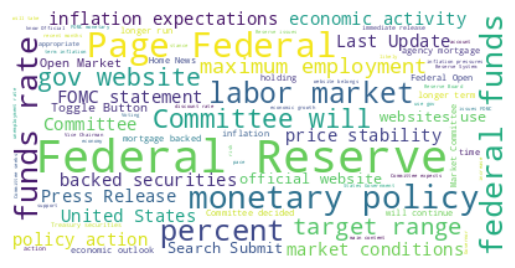

In [ ]:
trans_text = " ".join(transcript_df["text"])
wordcloud = WordCloud(background_color="white").generate(statement_text)

plt.imshow(wordcloud, interpolation="bilinear")
plt.savefig("transcriptWordCloud.png", dpi=300, bbox_inches="tight")
plt.axis("off")
plt.show()

In [ ]:
transcript_df.to_csv("fomc_transcript.csv", index=False)

# Topic Modeling

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
transcript_artifacts = {"unintelligible","laughter","applause"}
speaker_names = {
    "greenspan", "burns", "axilrod", "wallich", "partee", "gramley", "solomon",
    "hoskins", "syron", "johnson", "keehn", "mayo","melzer", "balles",
    "fisher", "jordan", "minehan", "hoenig", "teeters", "angell", "mcdonough",
    "roos","coldwell","schultz","steve","winn","kichline","pardee","bernanke",
    "martin","ford","boykin","jackson","connell","phillips","kelley","miller",
    "parry","seger","forrestal", "mullins","mike","laware","heller"
}
polite_fillers = {
    "please","thanks","thank","thankyou","thank-you",
    "madam","sir","chair","chairman","chairwoman","mr","ms","mrs"
}
month_words = {
    "january","february","march","april","may","june","july","august","september","october","november","december",
    "jan","feb","mar","apr","jun","jul","aug","sep","sept","oct","nov","dec"
}
domain_stop = {
    "federal","reserve","board","committee","policy","statement","meeting",
    "percent","rates","rate","economy","economic","financial","market","markets"
}
stop_words = set(stopwords.words('english')) | domain_stop | transcript_artifacts | polite_fillers | month_words | speaker_names

In [ ]:
#Function for Tokenization
def tokenize_doc(s: str):
    # Lowercase and remove unwanted characters
    s = re.sub(r"[^a-zA-Z0-9\s]", " ", s or "")  # keep only alphnumeric and spaces
    s = re.sub(r"\s+", " ", s).strip().lower()
    tokens = nltk.word_tokenize(s)
    # Remove stopwords and very short tokens
    return [t for t in tokens if t not in stop_words and len(t) > 2]

In [ ]:
# ---------------- CATEGORY MAPS ----------------
CATEGORY_MAP = {
    "expected measures objective indicators securities based energy adjustments near page":
        "Economic Indicators & Policy Objectives",
    "basis approved kohn donald sustainable discount prices timothy geithner believes":
        "Discount Rate Decisions & Policy Endorsements",
    "appropriate goals securities agency achieve account assessments implications treasury take":
        "Policy Goals & Treasury Market Operations",
    "page search official button gov securities submit website websites toggle":
        "Webpage Metadata / Non-Policy Content",
    "discount banks approved basis bank 2001 available accessibility long demand":
        "Discount Window & Bank Lending Conditions",
}

CATEGORY_MAP_TRANSCRIPTS = {
    # Topic 00
    "productivity gdp asymmetric cpi symmetric workers wages mcteer 1997 region":
        "Economic Activity & Inflation Dynamics",

    # Topic 01
    "collateral swap sheet facility dudley repo option options primary lacker":
        "Monetary Operations & Financial Instruments",

    # Topic 02
    "yen asia productivity asian cross gardner lilly panel crisis currencies":
        "International & Exchange Rate Issues",

    # Topic 03
    "court release memorandum transcripts broida letter edited holmes request department":
        "Administrative & Legal Communications",

    # Topic 04
    "velocity rice sentence midpoint borrowings nonborrowed cross chuck henry 1980":
        "Money & Credit Aggregates",
}

In [ ]:
import unicodedata

def normalize_label(s: str) -> str:
    if s is None:
        return ""
    s = unicodedata.normalize("NFKC", str(s)).lower()
    s = s.replace("\xa0", " ").replace("\u2009", " ").replace("\u2002", " ")
    s = re.sub(r"[^a-z0-9]+", " ", s)           # <-- assign the regex-cleaned string
    s = re.sub(r"\s+", " ", s).strip()          # <-- collapse whitespace
    return s

def tokens_key(s: str) -> frozenset:
    # order-insensitive token set; split on whitespace
    s = normalize_label(s)
    toks = s.split(" ")
    toks = [t for t in toks if t]
    return frozenset(toks)

# active category map (can switch globally)
ACTIVE_CATEGORY_MAP = CATEGORY_MAP

def categorize_label(s: str, default="Other/Unmapped") -> str:
    input_tokens = tokens_key(s)
    best_label, best_score = default, 0.0

    for k, v in ACTIVE_CATEGORY_MAP.items() if 'ACTIVE_CATEGORY_MAP' in globals() else CATEGORY_MAP.items():
        k_tokens = tokens_key(k)
        inter = len(input_tokens & k_tokens)
        union = len(input_tokens | k_tokens) or 1
        jacc = inter / union
        # Prefer categories with >=3 overlapping tokens; tie-break on Jaccard
        score = (inter >= 3, jacc)
        if score > (best_score >= 3, best_score if best_score <= 1 else best_score):
            best_label, best_score = v, jacc

    return best_label if (len(input_tokens) and best_score >= 0.30) else default



In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.9 MB/s eta 0:00:00


In [ ]:
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel

def lda_topic_model_dataframe(
    df,
    text_col="text",
    num_topics=5,
    no_below=5,
    no_above=0.5,
    random_state=42,
    passes=10,
    chunksize=2000,
    use_transcript_map=False
):
    """
    Runs LDA topic modeling and categorization on a dataframe.
    - If use_transcript_map=True, uses CATEGORY_MAP_TRANSCRIPTS.
    - Otherwise uses CATEGORY_MAP.
    Returns the augmented dataframe and lda artifacts.
    """

    global ACTIVE_CATEGORY_MAP
    ACTIVE_CATEGORY_MAP = CATEGORY_MAP_TRANSCRIPTS if use_transcript_map else CATEGORY_MAP

    # 1) tokenize
    docs = df[text_col].fillna("").astype(str).tolist()
    tokenized_docs = [tokenize_doc(t) for t in docs]

    # 2) dictionary & corpus
    dictionary = Dictionary(tokenized_docs)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    corpus = [dictionary.doc2bow(toks) for toks in tokenized_docs]

    # 3) train LDA
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=random_state,
        chunksize=chunksize,
        passes=passes,
        alpha="auto",
        eta="auto",
    )

    # helper to get top keywords
    def topic_keywords(topic_id, topn=10):
        terms = lda.get_topic_terms(topic_id, topn=topn)
        words = [dictionary[w_id] for w_id, _ in terms]
        return " ".join(words)

    # 4) assign dominant topic
    doc_dom_topic, doc_dom_prob, doc_topic_kw = [], [], []
    for bow in corpus:
        dist = lda[bow]
        if not dist:
            doc_dom_topic.append(None)
            doc_dom_prob.append(None)
            doc_topic_kw.append("")
            continue
        best_topic, best_prob = max(dist, key=lambda x: x[1])
        doc_dom_topic.append(int(best_topic))
        doc_dom_prob.append(float(best_prob))
        doc_topic_kw.append(topic_keywords(best_topic))

    # 5) attach columns + categorize
    out = df.copy()
    out["topic_id"] = doc_dom_topic
    out["topic_conf"] = doc_dom_prob
    out["topic_label"] = doc_topic_kw
    out["topic_category"] = out["topic_label"].apply(categorize_label)

    return out, {"lda": lda, "dictionary": dictionary, "corpus": corpus}


In [ ]:
# For statements
lab_statement_df, lda_artifacts_statements = lda_topic_model_dataframe(
    statement_df, text_col="text", use_transcript_map=False
)

In [ ]:
# For transcripts
lab_transcript_df, lda_artifacts_transcripts = lda_topic_model_dataframe(
    transcript_df, text_col="text", use_transcript_map=True
)


In [ ]:
lab_statement_df.head(3)

,url,doc_type,date,text,year,meeting,text_len,sentiment,conf,score,...,emotion_anger,emotion_disgust,emotion_fear,emotion_happiness,emotion_sadness,emotion_surprise,topic_id,topic_conf,topic_label,topic_category
231,https://www.federalreserve.gov/fomc/19940204de...,statement,1994-02-04,For immediate release Chairman Alan Greenspan ...,1994,19940204default.htm,735,neutral,0.864258,0.048309,...,0.026658,0.001022,0.034436,0.063610,0.018073,0.856201,2,0.993540,discount approved basis accessibility sustaina...,Discount Window & Bank Lending Conditions
234,https://www.federalreserve.gov/fomc/19940322de...,statement,1994-03-22,For immediate release Chairman Alan Greenspan ...,1994,19940322default.htm,357,neutral,0.870117,0.048035,...,0.080757,0.001839,0.092863,0.076495,0.304900,0.443146,2,0.988238,discount approved basis accessibility sustaina...,Discount Window & Bank Lending Conditions
237,https://www.federalreserve.gov/fomc/19940418de...,statement,1994-04-18,For immediate release Chairman Alan Greenspan ...,1994,19940418default.htm,337,neutral,0.895996,0.020111,...,0.077296,0.001599,0.106173,0.048285,0.458806,0.307841,2,0.988238,discount approved basis accessibility sustaina...,Discount Window & Bank Lending Conditions


In [ ]:
lab_statement_df['topic_category'].value_counts()

,count
topic_category,
Webpage Metadata / Non-Policy Content,94
Discount Window & Bank Lending Conditions,71
Policy Goals & Treasury Market Operations,44
Economic Indicators & Policy Objectives,33


In [ ]:
lab_transcript_df.head(3)

,url,doc_type,date,text,year,meeting,text_len,sentiment,conf,score,...,emotion_anger,emotion_disgust,emotion_fear,emotion_happiness,emotion_sadness,emotion_surprise,topic_id,topic_conf,topic_label,topic_category
0,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-03-29,"Mr. Kalchbrenner, Adviser FEDERAL OPEN MARKET ...",1976,FOMC19760329meeting.pdf,114446,neutral,0.857422,-0.041656,...,0.118514,0.002651,0.314349,0.324190,0.048959,0.191337,3,0.997809,court release memorandum transcripts broida le...,Administrative & Legal Communications
1,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-04-20,A meeting of the Federal Open Market Committee...,1976,FOMC19760420meeting.pdf,215941,neutral,0.817871,-0.026917,...,0.158297,0.002581,0.221813,0.345324,0.041299,0.230685,3,0.999895,court release memorandum transcripts broida le...,Administrative & Legal Communications
2,https://www.federalreserve.gov/monetarypolicy/...,transcript,1976-05-18,"Mr. Sternlight, Deputy Manager for Domestic Op...",1976,FOMC19760518meeting.pdf,149622,neutral,0.823730,-0.006775,...,0.122318,0.002380,0.256952,0.332976,0.053054,0.232319,3,0.900091,court release memorandum transcripts broida le...,Administrative & Legal Communications


In [ ]:
lab_transcript_df['topic_category'].value_counts()

,count
topic_category,
Money & Credit Aggregates,120
Economic Activity & Inflation Dynamics,89
Administrative & Legal Communications,32
International & Exchange Rate Issues,28
Monetary Operations & Financial Instruments,24


In [ ]:
#!pip install gensim

In [ ]:
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel
#Perform tokenization on the data

docs = transcript_df["text"].fillna("").astype(str).tolist()
tokenized_docs = [tokenize_doc(t) for t in docs]

#Create a dictionary of all the created tokens
dictionary = Dictionary(tokenized_docs)
dictionary.filter_extremes(no_below=5, no_above=0.5)

#Club the tokens in a corpus
corpus = [dictionary.doc2bow(toks) for toks in tokenized_docs]

len(dictionary), len(corpus[:10])

(10116, 10)

In [ ]:
NUM_TOPICS = 5
lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    chunksize=2000,
    passes=10,
    alpha='auto',
    eta='auto'
)

# Show top 10 words per topic
for i, terms in lda.show_topics(num_topics=NUM_TOPICS, num_words=10, formatted=False):
    print(f"Topic {i:02d}: " + ", ".join([w for w,_ in terms]))

Topic 00: productivity, gdp, asymmetric, cpi, symmetric, workers, wages, mcteer, 1997, region
Topic 01: collateral, swap, sheet, facility, dudley, repo, option, options, primary, lacker
Topic 02: yen, asia, productivity, asian, cross, gardner, lilly, panel, crisis, currencies
Topic 03: court, release, memorandum, transcripts, broida, letter, edited, holmes, request, department
Topic 04: velocity, rice, sentence, midpoint, borrowings, nonborrowed, cross, chuck, henry, 1980


In [ ]:
# Check for any unmapped categories
unmapped_mask = (
    lab_statement_df["topic_category"].isna()
    | lab_statement_df["topic_category"].str.lower().eq("other/unmapped")
)

print("Unique mapped categories:", lab_statement_df["topic_category"].unique())

unmapped_labels = (
    lab_statement_df.loc[unmapped_mask, "topic_label"]
      .dropna()
      .unique()
      .tolist()
)

if unmapped_labels:
    print("\n--- Unmapped examples (raw / normalized / tokens) ---")
    for s in unmapped_labels[:10]:
        print("RAW:", repr(s))
        print("NORM:", normalize_label(s))
        print("TOKS:", sorted(tokens_key(s)))
        print("---")
else:
    print("\nNo unmapped labels found (including case-insensitive).")


Unique mapped categories: ['Discount Window & Bank Lending Conditions'
 'Webpage Metadata / Non-Policy Content'
 'Economic Indicators & Policy Objectives'
 'Policy Goals & Treasury Market Operations']

No unmapped labels found (including case-insensitive).


In [ ]:
lab_statement_df.to_csv("fomc_statement_topics.csv", index=False)

In [ ]:
lab_transcript_df.to_csv("fomc_transcript_topics.csv", index=False)

###Merging Data

In [ ]:
vix_df = pd.read_csv('/content/VIXCLS.csv')
vix_df.head()

,observation_date,VIXCLS
0,1/2/1990,17.24
1,1/3/1990,18.19
2,1/4/1990,19.22
3,1/5/1990,20.11
4,1/8/1990,20.26


In [ ]:
vix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9320 entries, 0 to 9319
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  9320 non-null   object 
 1   VIXCLS            9021 non-null   float64
dtypes: float64(1), object(1)
memory usage: 145.8+ KB


In [ ]:
vix_df.isna().sum()

,0
observation_date,0
VIXCLS,299


In [ ]:
vix_df = vix_df.dropna(subset=['VIXCLS'])

In [ ]:
display(lab_statement_df.info())
display(lab_transcript_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 242 entries, 231 to 771
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   url                242 non-null    object        
 1   doc_type           242 non-null    object        
 2   date               242 non-null    datetime64[ns]
 3   text               242 non-null    object        
 4   year               242 non-null    int64         
 5   meeting            202 non-null    object        
 6   text_len           242 non-null    int64         
 7   sentiment          242 non-null    object        
 8   conf               242 non-null    float64       
 9   score              242 non-null    float64       
 10  emotion_label      242 non-null    object        
 11  emotion_neutral    242 non-null    float64       
 12  emotion_anger      242 non-null    float64       
 13  emotion_disgust    242 non-null    float64       
 14  emotion_fear 

None

<class 'pandas.core.frame.DataFrame'>
Index: 293 entries, 0 to 662
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   url                293 non-null    object        
 1   doc_type           293 non-null    object        
 2   date               293 non-null    datetime64[ns]
 3   text               293 non-null    object        
 4   year               293 non-null    int64         
 5   meeting            293 non-null    object        
 6   text_len           293 non-null    int64         
 7   sentiment          293 non-null    object        
 8   conf               293 non-null    float64       
 9   score              293 non-null    float64       
 10  emotion_label      293 non-null    object        
 11  emotion_neutral    293 non-null    float64       
 12  emotion_anger      293 non-null    float64       
 13  emotion_disgust    293 non-null    float64       
 14  emotion_fear   

None

In [ ]:
vix_df['observation_date'] = vix_df['observation_date'].astype('datetime64[ns]')

In [ ]:
combined_df = pd.concat([lab_statement_df, lab_transcript_df], axis=0)
combined_df.head(3)

,url,doc_type,date,text,year,meeting,text_len,sentiment,conf,score,...,emotion_anger,emotion_disgust,emotion_fear,emotion_happiness,emotion_sadness,emotion_surprise,topic_id,topic_conf,topic_label,topic_category
231,https://www.federalreserve.gov/fomc/19940204de...,statement,1994-02-04,For immediate release Chairman Alan Greenspan ...,1994,19940204default.htm,735,neutral,0.864258,0.048309,...,0.026658,0.001022,0.034436,0.063610,0.018073,0.856201,2,0.993540,discount approved basis accessibility sustaina...,Discount Window & Bank Lending Conditions
234,https://www.federalreserve.gov/fomc/19940322de...,statement,1994-03-22,For immediate release Chairman Alan Greenspan ...,1994,19940322default.htm,357,neutral,0.870117,0.048035,...,0.080757,0.001839,0.092863,0.076495,0.304900,0.443146,2,0.988238,discount approved basis accessibility sustaina...,Discount Window & Bank Lending Conditions
237,https://www.federalreserve.gov/fomc/19940418de...,statement,1994-04-18,For immediate release Chairman Alan Greenspan ...,1994,19940418default.htm,337,neutral,0.895996,0.020111,...,0.077296,0.001599,0.106173,0.048285,0.458806,0.307841,2,0.988238,discount approved basis accessibility sustaina...,Discount Window & Bank Lending Conditions


In [ ]:
combined_df.drop(columns=['url', 'text', 'meeting', 'topic_id', 'topic_label'], inplace=True)
combined_df.head(3)

,doc_type,date,year,text_len,sentiment,conf,score,emotion_label,emotion_neutral,emotion_anger,emotion_disgust,emotion_fear,emotion_happiness,emotion_sadness,emotion_surprise,topic_conf,topic_category
231,statement,1994-02-04,1994,735,neutral,0.864258,0.048309,surprise,0.072327,0.026658,0.001022,0.034436,0.063610,0.018073,0.856201,0.993540,Discount Window & Bank Lending Conditions
234,statement,1994-03-22,1994,357,neutral,0.870117,0.048035,surprise,0.097717,0.080757,0.001839,0.092863,0.076495,0.304900,0.443146,0.988238,Discount Window & Bank Lending Conditions
237,statement,1994-04-18,1994,337,neutral,0.895996,0.020111,sadness,0.091064,0.077296,0.001599,0.106173,0.048285,0.458806,0.307841,0.988238,Discount Window & Bank Lending Conditions


In [ ]:
combined_df['doc_type'].value_counts()

,count
doc_type,
transcript,293
statement,242


In [ ]:
merged_df = pd.merge(vix_df, combined_df, left_on='observation_date', right_on='date', how='left')
merged_df.head()

,observation_date,VIXCLS,doc_type,date,year,text_len,sentiment,conf,score,emotion_label,emotion_neutral,emotion_anger,emotion_disgust,emotion_fear,emotion_happiness,emotion_sadness,emotion_surprise,topic_conf,topic_category
0,1990-01-02,17.24,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1990-01-03,18.19,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1990-01-04,19.22,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-01-05,20.11,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1990-01-08,20.26,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
merged_df['topic_category'].value_counts()

,count
topic_category,
Webpage Metadata / Non-Policy Content,93
Discount Window & Bank Lending Conditions,71
Economic Activity & Inflation Dynamics,69
Policy Goals & Treasury Market Operations,43
Economic Indicators & Policy Objectives,33
Monetary Operations & Financial Instruments,19
Administrative & Legal Communications,16
International & Exchange Rate Issues,14


In [ ]:
merged_df['doc_type'].value_counts()

,count
doc_type,
statement,240
transcript,118


In [ ]:
merged_df = merged_df.drop(columns=['date'])

In [ ]:
merged_df.to_csv('FinalVIX.csv')
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9021 entries, 0 to 9020
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   observation_date   9021 non-null   datetime64[ns]
 1   VIXCLS             9021 non-null   float64       
 2   doc_type           358 non-null    object        
 3   year               358 non-null    float64       
 4   text_len           358 non-null    float64       
 5   sentiment          358 non-null    object        
 6   conf               358 non-null    float64       
 7   score              358 non-null    float64       
 8   emotion_label      358 non-null    object        
 9   emotion_neutral    358 non-null    float64       
 10  emotion_anger      358 non-null    float64       
 11  emotion_disgust    358 non-null    float64       
 12  emotion_fear       358 non-null    float64       
 13  emotion_happiness  358 non-null    float64       
 14  emotion_

In [ ]:
merged_df = merged_df.dropna(subset=['VIXCLS'])
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9021 entries, 0 to 9020
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   observation_date   9021 non-null   datetime64[ns]
 1   VIXCLS             9021 non-null   float64       
 2   doc_type           358 non-null    object        
 3   year               358 non-null    float64       
 4   text_len           358 non-null    float64       
 5   sentiment          358 non-null    object        
 6   conf               358 non-null    float64       
 7   score              358 non-null    float64       
 8   emotion_label      358 non-null    object        
 9   emotion_neutral    358 non-null    float64       
 10  emotion_anger      358 non-null    float64       
 11  emotion_disgust    358 non-null    float64       
 12  emotion_fear       358 non-null    float64       
 13  emotion_happiness  358 non-null    float64       
 14  emotion_

## Regression Analysis

In [ ]:
import statsmodels.api as sm
from pathlib import Path

In [ ]:
# ---------- CONFIG ----------
CSV_PATH = "/content/FinalVIX.csv"          # path to your file
DROP_INDEX_LIKE = True             # drop columns like "Unnamed: 0"
OUTDIR = Path(".")                 # where to save CSV outputs
target = "VIXCLS"

In [ ]:
def standardized_betas(params, X_with_const, y):
    """Return standardized betas aligned to params' index (NaN for const)."""
    y_sd = y.std(ddof=1)
    if y_sd == 0 or np.isnan(y_sd):
        return pd.Series(index=params.index, dtype=float)
    # exclude const for sd calc
    Xsd = X_with_const.drop(columns=["const"], errors="ignore").std(ddof=1)
    betas = params.drop(labels=["const"], errors="ignore") * (Xsd / y_sd)
    betas = betas.reindex(params.index)
    betas.loc["const"] = np.nan
    return betas

In [ ]:
def main():
    OUTDIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(CSV_PATH)
    df = df.dropna(how='any')

    if DROP_INDEX_LIKE:
        drop_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
        df = df.drop(columns=drop_cols, errors="ignore")



    #Convert categorical columns to dummy variables
    cat_cols = ["doc_type", "sentiment", "topic_category"]
    print("Categorical columns detected:", cat_cols)

    if cat_cols:
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=float)
        print("Dummy variables created")

    # choose predictors
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    predictors = [c for c in numeric_cols if c != target]

    dummy_like = [c for c in predictors if any(k in c for k in ["doc_type_", "sentiment_", "topic_category_"])]
    print("Dummy predictors present:", dummy_like)

    # listwise delete on model vars
    model_df = df[predictors + [target]].dropna()
    y = model_df[target].astype(float)
    X = model_df[predictors].astype(float)
    Xc = sm.add_constant(X, has_constant="add")

    model = sm.OLS(y, Xc).fit()

    # ---------- PSPP-like tables ----------
    # Model Summary
    R2 = model.rsquared
    AdjR2 = model.rsquared_adj
    R = np.sqrt(R2)
    std_error_est = np.sqrt(model.mse_resid)
    model_summary = pd.DataFrame({
        "R": [R],
        "R Square": [R2],
        "Adjusted R Square": [AdjR2],
        "Std. Error of the Estimate": [std_error_est]
    })

    # ANOVA
    ss_resid = model.ssr
    try:
        ss_total = model.centered_tss
    except Exception:
        ss_total = float(np.sum((y - y.mean())**2))
    ss_model = ss_total - ss_resid
    df_model = int(model.df_model)
    df_resid = int(model.df_resid)
    df_total = df_model + df_resid
    ms_model = ss_model / df_model if df_model > 0 else np.nan
    ms_resid = ss_resid / df_resid if df_resid > 0 else np.nan

    anova_table = pd.DataFrame({
        "": ["Regression", "Residual", "Total"],
        "Sum of Squares": [ss_model, ss_resid, ss_total],
        "df": [df_model, df_resid, df_total],
        "Mean Square": [ms_model, ms_resid, ""],
        "F": [model.fvalue, "", ""],
        "Sig.": [model.f_pvalue, "", ""]
    })

    # Coefficients (unstandardized + standardized)
    params = model.params
    se = model.bse
    tvals = model.tvalues
    pvals = model.pvalues
    betas = standardized_betas(params, Xc, y)

    coeffs = pd.DataFrame({
        "": params.index,
        "Unstandardized Coefficients (B)": params.values,
        "Std. Error": se.values,
        "Standardized Coefficients (Beta)": betas.values,
        "t": tvals.values,
        "Sig.": pvals.values
    })

    # ---------- Output ----------
    print("\n=== MODEL SUMMARY ===")
    print(model_summary.to_string(index=False))
    print("\n=== ANOVA ===")
    print(anova_table.to_string(index=False))
    print("\n=== COEFFICIENTS ===")
    print(coeffs.to_string(index=False))

    # Optional: full statsmodels summary text
    with (OUTDIR / "vix_full_summary.txt").open("w", encoding="utf-8") as f:
        f.write(model.summary().as_text())

    print("\nSaved:")
    print(f"- {OUTDIR / 'vix_full_summary.txt'}")
    print(f"\nDependent variable: {target}")
    print(f"Predictors ({len(predictors)}): {', '.join(predictors)}")
    print(f"Cases used (listwise): {len(model_df)}")


In [ ]:
if __name__ == "__main__":
    main()

Categorical columns detected: ['doc_type', 'sentiment', 'topic_category']
Dummy variables created
Dummy predictors present: ['doc_type_transcript', 'sentiment_neutral', 'sentiment_positive', 'topic_category_Discount Window & Bank Lending Conditions', 'topic_category_Economic Activity & Inflation Dynamics', 'topic_category_Economic Indicators & Policy Objectives', 'topic_category_International & Exchange Rate Issues', 'topic_category_Monetary Operations & Financial Instruments', 'topic_category_Policy Goals & Treasury Market Operations', 'topic_category_Webpage Metadata / Non-Policy Content']

=== MODEL SUMMARY ===
       R  R Square  Adjusted R Square  Std. Error of the Estimate
0.485632  0.235839           0.190488                    8.108094

=== ANOVA ===
            Sum of Squares  df Mean Square         F Sig.
Regression     6837.494510  20  341.874726  5.200313  0.0
  Residual    22154.779476 337   65.741185               
     Total    28992.273987 357                           

In [ ]:
df = pd.read_csv(CSV_PATH)
df = df.dropna(how='any')
df.head()

,Unnamed: 0,observation_date,VIXCLS,doc_type,year,text_len,sentiment,conf,score,emotion_label,emotion_neutral,emotion_anger,emotion_disgust,emotion_fear,emotion_happiness,emotion_sadness,emotion_surprise,topic_conf,topic_category
26,26,1990-02-07,24.29,transcript,1990.0,170917.0,neutral,0.575684,-0.164673,happiness,0.126953,0.120795,0.002250,0.209015,0.392305,0.044809,0.230825,0.921667,Economic Activity & Inflation Dynamics
59,59,1990-03-27,21.01,transcript,1990.0,245556.0,neutral,0.680664,-0.105469,happiness,0.111816,0.119755,0.002246,0.218074,0.425430,0.038407,0.196088,0.642345,International & Exchange Rate Issues
70,70,1990-04-11,17.73,transcript,1990.0,17678.0,neutral,0.612305,-0.230469,fear,0.109070,0.121742,0.001946,0.443397,0.206489,0.056932,0.169494,0.998698,International & Exchange Rate Issues
93,93,1990-05-15,19.49,transcript,1990.0,108397.0,neutral,0.425293,-0.240845,happiness,0.113831,0.107379,0.002150,0.267654,0.359536,0.042600,0.220681,0.993450,Economic Activity & Inflation Dynamics
127,127,1990-07-03,16.11,transcript,1990.0,169129.0,neutral,0.542480,-0.244995,happiness,0.127319,0.109870,0.002288,0.219041,0.383811,0.041053,0.243938,0.936119,Economic Activity & Inflation Dynamics


In [ ]:
drop_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
df = df.drop(columns=drop_cols, errors="ignore")
df.head()

,observation_date,VIXCLS,doc_type,year,text_len,sentiment,conf,score,emotion_label,emotion_neutral,emotion_anger,emotion_disgust,emotion_fear,emotion_happiness,emotion_sadness,emotion_surprise,topic_conf,topic_category
26,1990-02-07,24.29,transcript,1990.0,170917.0,neutral,0.575684,-0.164673,happiness,0.126953,0.120795,0.002250,0.209015,0.392305,0.044809,0.230825,0.921667,Economic Activity & Inflation Dynamics
59,1990-03-27,21.01,transcript,1990.0,245556.0,neutral,0.680664,-0.105469,happiness,0.111816,0.119755,0.002246,0.218074,0.425430,0.038407,0.196088,0.642345,International & Exchange Rate Issues
70,1990-04-11,17.73,transcript,1990.0,17678.0,neutral,0.612305,-0.230469,fear,0.109070,0.121742,0.001946,0.443397,0.206489,0.056932,0.169494,0.998698,International & Exchange Rate Issues
93,1990-05-15,19.49,transcript,1990.0,108397.0,neutral,0.425293,-0.240845,happiness,0.113831,0.107379,0.002150,0.267654,0.359536,0.042600,0.220681,0.993450,Economic Activity & Inflation Dynamics
127,1990-07-03,16.11,transcript,1990.0,169129.0,neutral,0.542480,-0.244995,happiness,0.127319,0.109870,0.002288,0.219041,0.383811,0.041053,0.243938,0.936119,Economic Activity & Inflation Dynamics


In [ ]:
cat_cols = ["doc_type", "sentiment", "topic_category"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=float)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 358 entries, 26 to 9017
Data columns (total 25 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   observation_date                                            358 non-null    object 
 1   VIXCLS                                                      358 non-null    float64
 2   year                                                        358 non-null    float64
 3   text_len                                                    358 non-null    float64
 4   conf                                                        358 non-null    float64
 5   score                                                       358 non-null    float64
 6   emotion_label                                               358 non-null    object 
 7   emotion_neutral                                             358 non-null    float64
 8   emo

In [ ]:
 # choose predictors
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
predictors = [c for c in numeric_cols if c != target]

In [ ]:
# listwise delete on model vars
model_df = df[predictors + [target]]
y = model_df[target].astype(float)
X = model_df[predictors].astype(float)
Xc = sm.add_constant(X, has_constant="add")

model = sm.OLS(y, Xc).fit()

In [ ]:
# ---------- PSPP-like tables ----------
    # Model Summary
R2 = model.rsquared
AdjR2 = model.rsquared_adj
R = np.sqrt(R2)
std_error_est = np.sqrt(model.mse_resid)
model_summary = pd.DataFrame({
    "R": [R],
    "R Square": [R2],
    "Adjusted R Square": [AdjR2],
    "Std. Error of the Estimate": [std_error_est]
})


In [ ]:
# ANOVA
ss_resid = model.ssr
try:
    ss_total = model.centered_tss
except Exception:
    ss_total = float(np.sum((y - y.mean())**2))
ss_model = ss_total - ss_resid
df_model = int(model.df_model)
df_resid = int(model.df_resid)
df_total = df_model + df_resid
ms_model = ss_model / df_model if df_model > 0 else np.nan
ms_resid = ss_resid / df_resid if df_resid > 0 else np.nan

anova_table = pd.DataFrame({
  "": ["Regression", "Residual", "Total"],
  "Sum of Squares": [ss_model, ss_resid, ss_total],
  "df": [df_model, df_resid, df_total],
  "Mean Square": [ms_model, ms_resid, ""],
  "F": [model.fvalue, "", ""],
  "Sig.": [model.f_pvalue, "", ""]
})

In [ ]:
# Coefficients (unstandardized + standardized)
params = model.params
se = model.bse
tvals = model.tvalues
pvals = model.pvalues
betas = standardized_betas(params, Xc, y)

coeffs = pd.DataFrame({
    "": params.index,
    "Unstandardized Coefficients (B)": params.values,
    "Std. Error": se.values,
    "Standardized Coefficients (Beta)": betas.values,
    "t": tvals.values,
    "Sig.": pvals.values
})

In [ ]:
# ---------- Output ----------
print("\n=== MODEL SUMMARY ===")
print(model_summary.to_string(index=False))
print("\n=== ANOVA ===")
print(anova_table.to_string(index=False))
print("\n=== COEFFICIENTS ===")
print(coeffs.to_string(index=False))

# Optional: full statsmodels summary text
with (OUTDIR / "vix_full_summary.txt").open("w", encoding="utf-8") as f:
    f.write(model.summary().as_text())

print("\nSaved:")
print(f"- {OUTDIR / 'vix_full_summary.txt'}")
print(f"\nDependent variable: {target}")
print(f"Predictors ({len(predictors)}): {', '.join(predictors)}")
print(f"Cases used (listwise): {len(model_df)}")


=== MODEL SUMMARY ===
       R  R Square  Adjusted R Square  Std. Error of the Estimate
0.485632  0.235839           0.190488                    8.108094

=== ANOVA ===
            Sum of Squares  df Mean Square         F Sig.
Regression     6837.494510  20  341.874726  5.200313  0.0
  Residual    22154.779476 337   65.741185               
     Total    28992.273987 357                           

=== COEFFICIENTS ===
                                                            Unstandardized Coefficients (B)  Std. Error  Standardized Coefficients (Beta)         t     Sig.
                                                     const                      -163.575642  214.137368                               NaN -0.763882 0.445472
                                                      year                         0.097761    0.137510                          0.114416  0.710940 0.477613
                                                  text_len                         0.000003    0.000011  